<a href="https://colab.research.google.com/github/adithyarhm/nlp-sentiment_play_store/blob/main/%5BDICODING%5D_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Deep Learning Sentiment Analysis for Dicoding Submission

Notebook ini disusun untuk submission analisis sentimen berbasis deep learning menggunakan dataset hasil scraping mandiri dari Google Play Store. Label sentimen dibuat menjadi **3 kelas** dari rating aplikasi:
- **negative**: skor 1-2
- **neutral**: skor 3
- **positive**: skor 4-5

Notebook ini memuat **3 skema pelatihan deep learning**:
1. Embedding + GlobalAveragePooling1D
2. Embedding + Conv1D + GlobalMaxPooling1D
3. Embedding + Bidirectional LSTM

Di bagian akhir tersedia evaluasi, perbandingan model, penyimpanan artefak, dan inference pada contoh kalimat baru.


## 1. Import Library

In [ ]:
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, GlobalAveragePooling1D, Conv1D, GlobalMaxPooling1D, Bidirectional, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## 2. Load Dataset

In [ ]:
DATA_PATH = 'ulasan_aplikasi_clean.csv'
df = pd.read_csv(DATA_PATH)
print('Shape dataset awal:', df.shape)

Shape dataset awal: (30000, 11)


In [ ]:

df.columns.tolist()


['reviewId',
 'userName',
 'userImage',
 'content',
 'score',
 'thumbsUpCount',
 'reviewCreatedVersion',
 'at',
 'replyContent',
 'repliedAt',
 'appVersion']

## 3. Siapkan Kolom Teks dan Label

In [ ]:

text_candidates = ['textakhir', 'textclean', 'textslangwords', 'textcasefoldingText', 'content']
text_col = None
for col in text_candidates:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    raise ValueError('Kolom teks tidak ditemukan.')

print('Kolom teks yang digunakan:', text_col)


Kolom teks yang digunakan: content


In [ ]:
df = df[['content', 'score']].copy()
df = df.dropna()
df['content'] = df['content'].astype(str).str.strip()
df = df[df['content'] != '']

def map_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['label'] = df['score'].apply(map_sentiment)
label_encoder = LabelEncoder()
df['label_id'] = label_encoder.fit_transform(df['label'])
print('Data cleaning & labeling selesai.')

Data cleaning & labeling selesai.


In [ ]:

label_counts = df['label'].value_counts()
label_counts


,count
label,
positive,15436
negative,12486
neutral,2078


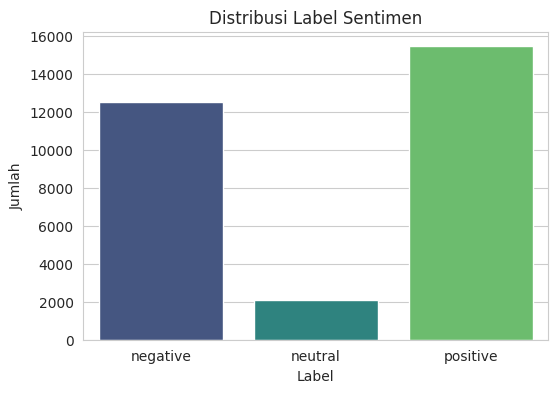

In [ ]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label', order=['negative','neutral','positive'], palette='viridis')
plt.title('Distribusi Label Sentimen')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()


## 4. Encoding Label dan Split Data

In [ ]:

label_encoder = LabelEncoder()
df['label_id'] = label_encoder.fit_transform(df['label'])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
inv_label_mapping = {v:k for k,v in label_mapping.items()}
print('Mapping label:', label_mapping)


Mapping label: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [ ]:
X = df['content'].values
y = df['label_id'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)
print('Split data selesai. Data train:', len(X_train))

Split data selesai. Data train: 24000


## 5. Tokenisasi dan Padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 20000
MAX_LEN = 100
EMBED_DIM = 256

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

num_classes = len(label_encoder.classes_)
actual_vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print('Tokenisasi ulang berhasil.')

Tokenisasi ulang berhasil.


## 6. Definisikan Fungsi Model dan Evaluasi

In [ ]:
from tensorflow.keras.layers import SpatialDropout1D

def build_model_gap(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.3),
        GlobalAveragePooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.5), # Increased dropout
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_model_cnn(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.3),
        Conv1D(128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.5), # Increased dropout
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_model_bilstm_v2(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.4),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3), # Added dropout layer
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_model_mlp_tfidf(input_dim, num_classes):
    model = Sequential([
        Dense(512, activation='relu', input_shape=(input_dim,)),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

def compile_model(model):
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)
    ]

def evaluate_model(model, X_test_pad, y_test, model_name):
    y_prob = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_test, y_pred,)
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    return acc, report, cm, y_pred

## 7. Training Skema 1 - Embedding + GlobalAveragePooling1D

In [ ]:

model_gap = build_model_gap(actual_vocab_size, EMBED_DIM, MAX_LEN, num_classes)
model_gap = compile_model(model_gap)
model_gap.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history_gap = model_gap.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=get_callbacks('gap'),
    verbose=1
)

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.6121 - loss: 0.8304 - val_accuracy: 0.7704 - val_loss: 0.6992 - learning_rate: 5.0000e-04
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7535 - loss: 0.6702 - val_accuracy: 0.8171 - val_loss: 0.5949 - learning_rate: 5.0000e-04
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7876 - loss: 0.5991 - val_accuracy: 0.8208 - val_loss: 0.5308 - learning_rate: 5.0000e-04
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.8005 - loss: 0.5640 - val_accuracy: 0.8313 - val_loss: 0.5115 - learning_rate: 5.0000e-04
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.8114 - loss: 0.5393 - val_accuracy: 0.8352 - val_loss: 0.5017 - learning_rate: 5.0000e-04
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - accuracy: 0.8220 - loss: 0.5180 - val_accuracy: 0.8367 - val_loss: 0.5139 - learning_rate: 5.0000e-04
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/ste

In [ ]:

acc_gap, report_gap, cm_gap, y_pred_gap = evaluate_model(model_gap, X_test_pad, y_test, 'GAP')
print('Test Accuracy GAP:', acc_gap)
pd.DataFrame(report_gap).transpose()


Test Accuracy GAP: 0.8381666666666666


,precision,recall,f1-score,support
negative,0.792945,0.900280,0.843211,2497.000000
neutral,0.142857,0.012019,0.022173,416.000000
positive,0.886901,0.899255,0.893035,3087.000000
accuracy,0.838167,0.838167,0.838167,0.838167
macro avg,0.607568,0.603852,0.586140,6000.000000
weighted avg,0.796213,0.838167,0.811920,6000.000000


## 8. Training Skema 2 - Embedding + Conv1D + GlobalMaxPooling1D

In [ ]:

model_cnn = build_model_cnn(actual_vocab_size, EMBED_DIM, MAX_LEN, num_classes)
model_cnn = compile_model(model_cnn)
model_cnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history_cnn = model_cnn.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=get_callbacks('cnn'),
    verbose=1
)


Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 70s 114ms/step - accuracy: 0.7889 - loss: 0.6008 - val_accuracy: 0.8425 - val_loss: 0.4846 - learning_rate: 5.0000e-04
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.8530 - loss: 0.4621 - val_accuracy: 0.8398 - val_loss: 0.4874 - learning_rate: 5.0000e-04
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 72s 120ms/step - accuracy: 0.8769 - loss: 0.3857 - val_accuracy: 0.8271 - val_loss: 0.5162 - learning_rate: 5.0000e-04
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8925 - loss: 0.3310
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
600/600 ━━━━━━━━━━━━━━━━━━━━ 77s 129ms/step - accuracy: 0.9016 - loss: 0.3107 - val_accuracy: 0.8263 - val_loss: 0.5657 - learning_rate: 5.0000e-04
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 76s 120ms/step - accuracy: 0.9310 - loss: 0.2320 - val_accuracy: 0.8229 - val_loss: 0.5863 - learning_rate: 1.0000e-04
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 69s 115ms/s

In [ ]:

acc_cnn, report_cnn, cm_cnn, y_pred_cnn = evaluate_model(model_cnn, X_test_pad, y_test, 'CNN')
print('Test Accuracy CNN:', acc_cnn)
pd.DataFrame(report_cnn).transpose()


Test Accuracy CNN: 0.8343333333333334


,precision,recall,f1-score,support
negative,0.781163,0.903484,0.837883,2497.000000
neutral,0.000000,0.000000,0.000000,416.000000
positive,0.883676,0.890833,0.887240,3087.000000
accuracy,0.834333,0.834333,0.834333,0.834333
macro avg,0.554947,0.598106,0.575041,6000.000000
weighted avg,0.779746,0.834333,0.805184,6000.000000


## 9. Training Skema 3 - Embedding + Bidirectional LSTM

In [ ]:
# Inisialisasi model BiLSTM versi 2 yang telah di-tuning
model_bilstm = build_model_bilstm_v2(actual_vocab_size, EMBED_DIM, MAX_LEN, num_classes)
model_bilstm = compile_model(model_bilstm)
model_bilstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Pelatihan ulang dengan batch size yang lebih kecil untuk generalisasi yang lebih baik
history_bilstm = model_bilstm.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=16,
    callbacks=get_callbacks('bilstm_v2'),
    verbose=1
)

Epoch 1/25
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 921s 757ms/step - accuracy: 0.7894 - loss: 0.6081 - val_accuracy: 0.8358 - val_loss: 0.4921 - learning_rate: 5.0000e-04
Epoch 2/25
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 920s 755ms/step - accuracy: 0.8462 - loss: 0.4929 - val_accuracy: 0.8440 - val_loss: 0.4934 - learning_rate: 5.0000e-04
Epoch 3/25
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 927s 760ms/step - accuracy: 0.8609 - loss: 0.4440 - val_accuracy: 0.8446 - val_loss: 0.5046 - learning_rate: 5.0000e-04
Epoch 4/25
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.8673 - loss: 0.4123
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 914s 753ms/step - accuracy: 0.8715 - loss: 0.4051 - val_accuracy: 0.8417 - val_loss: 0.5255 - learning_rate: 5.0000e-04
Epoch 5/25
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 899s 749ms/step - accuracy: 0.8806 - loss: 0.3604 - val_accuracy: 0.8417 - val_loss: 0.5351 - learning_rate: 1.0000e-04
Epoch 6/25
1200/1200 ━━━━━━━━━━━━━

In [ ]:

acc_bilstm, report_bilstm, cm_bilstm, y_pred_bilstm = evaluate_model(model_bilstm, X_test_pad, y_test, 'BiLSTM')
print('Test Accuracy BiLSTM:', acc_bilstm)
pd.DataFrame(report_bilstm).transpose()


Test Accuracy BiLSTM: 0.8368333333333333


,precision,recall,f1-score,support
negative,0.787678,0.906288,0.842831,2497.000000
neutral,0.000000,0.000000,0.000000,416.000000
positive,0.881996,0.893424,0.887673,3087.000000
accuracy,0.836833,0.836833,0.836833,0.836833
macro avg,0.556558,0.599904,0.576835,6000.000000
weighted avg,0.781592,0.836833,0.807466,6000.000000


## 9.1 Tokenisasi TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=MAX_WORDS)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print('TF-IDF vectorization selesai.')
print('Shape X_train_tfidf:', X_train_tfidf.shape)
print('Shape X_test_tfidf:', X_test_tfidf.shape)

TF-IDF vectorization selesai.
Shape X_train_tfidf: (24000, 13826)
Shape X_test_tfidf: (6000, 13826)


## 9.2 Training Skema 4 - MLP dengan TF-IDF

In [ ]:
input_dim_tfidf = X_train_tfidf.shape[1]

model_mlp_tfidf = build_model_mlp_tfidf(input_dim_tfidf, num_classes)
model_mlp_tfidf = compile_model(model_mlp_tfidf)
model_mlp_tfidf.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │     7,079,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,211,523 (27.51 MB)

 Trainable params: 7,211,523 (27.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_mlp_tfidf = model_mlp_tfidf.fit(
    X_train_tfidf.toarray(), y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=get_callbacks('mlp_tfidf'),
    verbose=1
)

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 59s 96ms/step - accuracy: 0.8021 - loss: 0.5811 - val_accuracy: 0.8388 - val_loss: 0.4793 - learning_rate: 5.0000e-04
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 57s 94ms/step - accuracy: 0.8573 - loss: 0.4315 - val_accuracy: 0.8310 - val_loss: 0.4959 - learning_rate: 5.0000e-04
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.8840 - loss: 0.3558 - val_accuracy: 0.8165 - val_loss: 0.5428 - learning_rate: 5.0000e-04
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9037 - loss: 0.3060
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
600/600 ━━━━━━━━━━━━━━━━━━━━ 86s 99ms/step - accuracy: 0.9105 - loss: 0.2906 - val_accuracy: 0.8079 - val_loss: 0.6083 - learning_rate: 5.0000e-04
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 57s 94ms/step - accuracy: 0.9348 - loss: 0.2260 - val_accuracy: 0.8138 - val_loss: 0.6233 - learning_rate: 1.0000e-04
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 56s 94ms/step - a

In [ ]:
acc_mlp_tfidf, report_mlp_tfidf, cm_mlp_tfidf, y_pred_mlp_tfidf = evaluate_model(model_mlp_tfidf, X_test_tfidf.toarray(), y_test, 'MLP_TFIDF')
print('Test Accuracy MLP TF-IDF:', acc_mlp_tfidf)
pd.DataFrame(report_mlp_tfidf).transpose()

Test Accuracy MLP TF-IDF: 0.8393333333333334


,precision,recall,f1-score,support
negative,0.785272,0.913897,0.844716,2497.000000
neutral,0.000000,0.000000,0.000000,416.000000
positive,0.890110,0.892128,0.891118,3087.000000
accuracy,0.839333,0.839333,0.839333,0.839333
macro avg,0.558461,0.602008,0.578611,6000.000000
weighted avg,0.784766,0.839333,0.810023,6000.000000


## 10. Bandingkan Semua Model

In [ ]:

results_df = pd.DataFrame([
    {'model': 'Embedding + GAP', 'test_accuracy': acc_gap},
    {'model': 'Embedding + CNN', 'test_accuracy': acc_cnn},
    {'model': 'Embedding + BiLSTM', 'test_accuracy': acc_bilstm},
]).sort_values(by='test_accuracy', ascending=False).reset_index(drop=True)

results_df


,model,test_accuracy
0,Embedding + GAP,0.838167
1,Embedding + BiLSTM,0.836833
2,Embedding + CNN,0.834333


In [ ]:
results_df = pd.DataFrame([
    {'model': 'Embedding + GAP', 'test_accuracy': acc_gap},
    {'model': 'Embedding + CNN', 'test_accuracy': acc_cnn},
    {'model': 'Embedding + BiLSTM', 'test_accuracy': acc_bilstm},
    {'model': 'MLP + TF-IDF', 'test_accuracy': acc_mlp_tfidf}
]).sort_values(by='test_accuracy', ascending=False).reset_index(drop=True)

results_df

,model,test_accuracy
0,MLP + TF-IDF,0.839333
1,Embedding + GAP,0.838167
2,Embedding + BiLSTM,0.836833
3,Embedding + CNN,0.834333


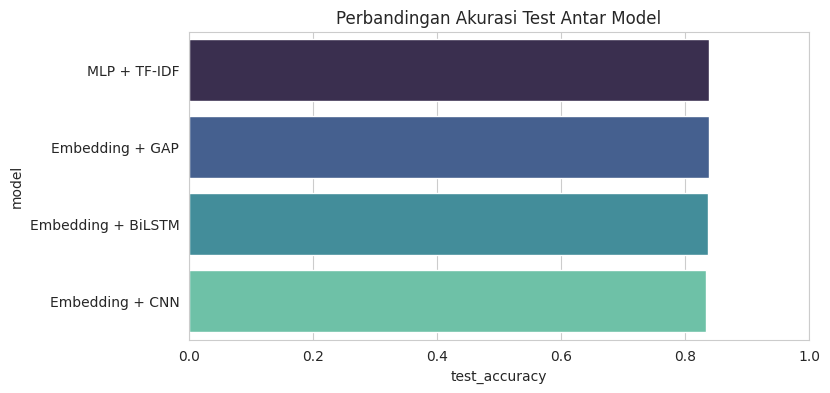

In [ ]:

plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x='test_accuracy', y='model', palette='mako')
plt.title('Perbandingan Akurasi Test Antar Model')
plt.xlim(0, 1)
plt.show()


## 11. Confusion Matrix Model Terbaik

In [ ]:

best_model_name = results_df.loc[0, 'model']

if best_model_name == 'Embedding + GAP':
    best_model = model_gap
    best_cm = cm_gap
elif best_model_name == 'Embedding + CNN':
    best_model = model_cnn
    best_cm = cm_cnn
else:
    best_model = model_bilstm
    best_cm = cm_bilstm

print('Model terbaik:', best_model_name)


Model terbaik: MLP + TF-IDF


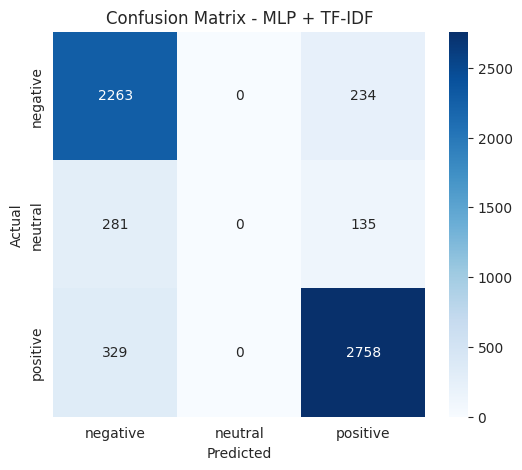

In [ ]:

plt.figure(figsize=(6,5))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 12. Simpan Artefak Model

In [ ]:

os.makedirs('submission_artifacts', exist_ok=True)

best_model.save('submission_artifacts/best_model.keras')

with open('submission_artifacts/tokenizer_config.json', 'w', encoding='utf-8') as f:
    json.dump(tokenizer.to_json(), f, ensure_ascii=False)

with open('submission_artifacts/label_mapping.json', 'w', encoding='utf-8') as f:
    json.dump({str(k): v for k, v in inv_label_mapping.items()}, f, ensure_ascii=False, indent=2)

results_df.to_csv('submission_artifacts/model_comparison.csv', index=False)

print('Artefak berhasil disimpan.')


Artefak berhasil disimpan.


## 13. Inference / Prediksi Kalimat Baru

In [ ]:

def predict_sentiment(text, model, tokenizer, max_len, inv_label_mapping):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    pred = model.predict(pad, verbose=0)
    label_id = int(np.argmax(pred, axis=1)[0])
    confidence = float(np.max(pred))
    label = inv_label_mapping[label_id]
    return label, confidence

sample_texts = [
    'aplikasinya sangat membantu dan fiturnya bagus',
    'biasa saja, tidak terlalu bagus tapi tidak jelek',
    'aplikasi ini buruk, sering error dan susah login'
]

for text in sample_texts:
    label, confidence = predict_sentiment(text, best_model, tokenizer, MAX_LEN, inv_label_mapping)
    print(f'Teks      : {text}')
    print(f'Prediksi  : {label}')
    print(f'Confidence: {confidence:.4f}')
    print('-'*60)


Teks      : aplikasinya sangat membantu dan fiturnya bagus
Prediksi  : positive
Confidence: 0.9681
------------------------------------------------------------
Teks      : biasa saja, tidak terlalu bagus tapi tidak jelek
Prediksi  : negative
Confidence: 0.8393
------------------------------------------------------------
Teks      : aplikasi ini buruk, sering error dan susah login
Prediksi  : negative
Confidence: 0.9944
------------------------------------------------------------


## 14. Kesimpulan Singkat

In [ ]:
print('Distribusi label:')
print(df['label'].value_counts())
print('\nHasil perbandingan model:')
print(results_df)

Distribusi label:
label
positive    15436
negative    12486
neutral      2078
Name: count, dtype: int64

Hasil perbandingan model:
                model  test_accuracy
0        MLP + TF-IDF       0.839333
1     Embedding + GAP       0.838167
2  Embedding + BiLSTM       0.836833
3     Embedding + CNN       0.834333
